# Notebook 03: Advanced Models — Chronos-2 + ST-GNN
## Sistem Peringatan Dini Dengue — Kota Bandung
**UNITY UNY #14 2026 | Core Novelty Stack**

---


In [1]:
!pip install --upgrade git+https://github.com/amazon-science/chronos-forecasting.git

  Cloning https://github.com/amazon-science/chronos-forecasting.git to /tmp/pip-req-build-c66tppyz
  Running command git clone --filter=blob:none --quiet https://github.com/amazon-science/chronos-forecasting.git /tmp/pip-req-build-c66tppyz
  Resolved https://github.com/amazon-science/chronos-forecasting.git to commit 32111085d85de6cc17d0ea4dd08adba324f57590
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 93.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 33.0 MB/s eta 0:00:00
  Created wheel for chronos-forecasting: filename=chronos_forecasting-2.2.2-py3-none-any.whl size=74105 sha256=27238339adb2760139250701a2e06fc232e5562207fac2eb350f83b949963467
  Stored in directory: /tmp/pip-ephem-wheel-cache-yv2i_t46/wheels/b9/a6/b5/75f

In [2]:
!pip install torch-geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 21.0 MB/s eta 0:00:00a 0:00:01


In [3]:
# ── 0. SETUP & DEPENDENCY CHECK ──────────────────────────────────────────────
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
import json, joblib

plt.rcParams.update({'figure.dpi':150,'figure.facecolor':'white',
    'axes.facecolor':'#fafafa','axes.spines.top':False,'axes.spines.right':False,
    'font.size':10,'axes.titlesize':12})
RED='#c0392b'; BLUE='#2980b9'; GREEN='#27ae60'; ORANGE='#e67e22'; PURPLE='#8e44ad'

FIGDIR   = Path('figures/advanced'); FIGDIR.mkdir(parents=True, exist_ok=True)
MODELDIR = Path('models');           MODELDIR.mkdir(exist_ok=True)
RESULTDIR= Path('results');          RESULTDIR.mkdir(exist_ok=True)

def mae(y,yh):   return mean_absolute_error(y,yh)
def rmse(y,yh):  return np.sqrt(mean_squared_error(y,yh))
def mase(y,yh,tr): return np.mean(np.abs(y-yh))/(np.mean(np.abs(np.diff(tr)))+1e-10)
def smape(y,yh): return 100*np.mean(2*np.abs(y-yh)/(np.abs(y)+np.abs(yh)+1e-10))
def evaluate(y, yhat, y_train, name):
    return {'Model':name, 'MAE':round(mae(y,yhat),4), 'RMSE':round(rmse(y,yhat),4),
            'MASE':round(mase(y,yhat,y_train),4), 'sMAPE':round(smape(y,yhat),4)}

# Dependency checks
try:
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
    HAS_TORCH = True
    DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
    print(f"✓ PyTorch {torch.__version__}  |  Device: {DEVICE}")
except ImportError:
    HAS_TORCH = False; print("✗ PyTorch missing — pip install torch")

try:
    from chronos import Chronos2Pipeline
    HAS_CHRONOS = True
    print("✓ Chronos-2 available")
except ImportError:
    HAS_CHRONOS = False
    print("✗ Chronos missing — pip install --upgrade git+https://github.com/amazon-science/chronos-forecasting.git")

try:
    import torch_geometric
    HAS_PYG = True
    print(f"✓ PyG {torch_geometric.__version__}")
except ImportError:
    HAS_PYG = False; print("✗ PyG missing — pip install torch-geometric")

ALL_RESULTS = []


✓ PyTorch 2.10.0+cu128  |  Device: cuda


2026-04-23 16:06:46.207618: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776960406.461265      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776960406.540573      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776960407.154127      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776960407.154176      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776960407.154179      55 computation_placer.cc:177] computation placer alr

✓ Chronos-2 available
✓ PyG 2.7.0


## 1. Load Data

In [4]:
DATA = Path('/kaggle/input/datasets/frallex/unydata')
df   = pd.read_csv(DATA/'panel_bulanan.csv', parse_dates=['date'])
node = pd.read_csv(DATA/'node_features.csv')
adj  = pd.read_csv(DATA/'adjacency.csv', index_col=0)

df = df.merge(node[['kecamatan','kepadatan_jiwa_km2']], on='kecamatan', how='left')
df = df.sort_values(['kecamatan','date']).reset_index(drop=True)
KECs = sorted(df['kecamatan'].unique())
N_KEC = len(KECs)

TRAIN_END = '2021-12-01'; VAL_END = '2022-12-01'
df_train = df[df['date'] <= TRAIN_END]
df_val   = df[(df['date'] > TRAIN_END) & (df['date'] <= VAL_END)]
df_test  = df[df['date'] > VAL_END]

# City-level aggregate
agg_train = df_train.groupby('date')['kasus_dbd'].sum()
agg_val   = df_val.groupby('date')['kasus_dbd'].sum()
agg_test  = df_test.groupby('date')['kasus_dbd'].sum()
agg_all   = df.groupby('date')['kasus_dbd'].sum()

print(f"Train: {len(agg_train)}m  |  Val: {len(agg_val)}m  |  Test: {len(agg_test)}m  |  Kecamatan: {N_KEC}")


Train: 72m  |  Val: 12m  |  Test: 24m  |  Kecamatan: 30


## 2. Chronos-2 Zero-Shot Forecasting

In [ ]:
# ── Chronos-2 Zero-Shot — Rolling 1-Step-Ahead Forecast ───────────────────────
# Instead of one 24-step forecast (error compounds badly at H=24),
# we do rolling 1-step-ahead: at each test month t, use ALL data up to t-1
# as context and predict t. This is the operationally correct EWS scenario
# ("predict next month using everything we know so far").
# Total API calls: 24 (test) + 12 (val, for hybrid weight optimization) = 36.

if HAS_CHRONOS:
    pipeline = Chronos2Pipeline.from_pretrained(
        "amazon/chronos-2",
        device_map=DEVICE,
    )

    test_dates_lst = sorted(agg_test.index)
    val_dates_lst  = sorted(agg_val.index)

    # ── Rolling predictions for TEST set ──────────────────────────────────────
    fc_roll = {'median': [], 'lo10': [], 'hi90': [], 'lo25': [], 'hi75': []}

    for i, test_date in enumerate(test_dates_lst):
        ctx_vals = agg_all[agg_all.index < test_date]   # all history before this month
        ctx_df   = pd.DataFrame({'id': 'bandung', 'date': ctx_vals.index,
                                  'target': ctx_vals.values.astype(np.float32)})
        preds_df = pipeline.predict_df(
            ctx_df,
            prediction_length = 1,
            quantile_levels   = [0.1, 0.25, 0.5, 0.75, 0.9],
            id_column='id', timestamp_column='date', target='target',
        )
        fc_roll['median'].append(max(float(preds_df['0.5'].values[0]), 0))
        fc_roll['lo10'].append(float(preds_df['0.1'].values[0]))
        fc_roll['hi90'].append(float(preds_df['0.9'].values[0]))
        fc_roll['lo25'].append(float(preds_df['0.25'].values[0]))
        fc_roll['hi75'].append(float(preds_df['0.75'].values[0]))
        if (i + 1) % 6 == 0:
            print(f"  Chronos ZS rolling test: {i+1}/{len(test_dates_lst)} months done")

    fc_median = np.array(fc_roll['median'])
    fc_lo10   = np.array(fc_roll['lo10'])
    fc_hi90   = np.array(fc_roll['hi90'])
    fc_lo25   = np.array(fc_roll['lo25'])
    fc_hi75   = np.array(fc_roll['hi75'])

    res_chronos0 = evaluate(agg_test.values, fc_median,
                             agg_train.values, 'Chronos-2 Zero-Shot')
    ALL_RESULTS.append(res_chronos0)
    print("Chronos-2 Zero-Shot (rolling 1-step):", res_chronos0)

    # Save test predictions
    pd.DataFrame({
        'date': test_dates_lst,
        'actual': agg_test.values,
        'chronos_zs_median': fc_median,
        'chronos_zs_lo10': fc_lo10,
        'chronos_zs_hi90': fc_hi90,
    }).to_csv(RESULTDIR/'chronos_zs_preds.csv', index=False)

    # ── Rolling predictions for VALIDATION set (needed for hybrid weights) ────
    print("  Computing Chronos val predictions for hybrid weight optimization...")
    chronos_val_preds = []
    for val_date in val_dates_lst:
        ctx_vals = agg_all[agg_all.index < val_date]
        ctx_df   = pd.DataFrame({'id': 'bandung', 'date': ctx_vals.index,
                                  'target': ctx_vals.values.astype(np.float32)})
        preds_df = pipeline.predict_df(ctx_df, prediction_length=1, quantile_levels=[0.5],
                                        id_column='id', timestamp_column='date', target='target')
        chronos_val_preds.append(max(float(preds_df['0.5'].values[0]), 0))
    chronos_val_preds = np.array(chronos_val_preds)
    np.save(MODELDIR/'chronos_val_preds.npy', chronos_val_preds)
    print(f"  ✓ Val preds saved  |  Val MAE: {np.mean(np.abs(agg_val.values - chronos_val_preds)):.3f}")

    # Plot
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.fill_between(agg_train.index[-24:], agg_train.values[-24:], alpha=0.2, color=BLUE)
    ax.plot(agg_train.index[-24:], agg_train.values[-24:], color=BLUE, linewidth=1.5, label='Train (last 24m)')
    ax.plot(agg_test.index, agg_test.values, color='black', linewidth=2, label='Actual (Test)')
    ax.fill_between(agg_test.index, fc_lo10, fc_hi90, alpha=0.18, color=RED, label='80% PI')
    ax.fill_between(agg_test.index, fc_lo25, fc_hi75, alpha=0.28, color=RED, label='50% PI')
    ax.plot(agg_test.index, fc_median, color=RED, linewidth=2.5, label='Chronos-2 Median (rolling 1-step)')
    ax.axvline(agg_test.index[0], color='gray', linestyle='--', linewidth=1.5)
    ax.set_title(f'Chronos-2 Zero-Shot (Rolling 1-Step) — MAE={res_chronos0["MAE"]:.3f} | RMSE={res_chronos0["RMSE"]:.3f}\n'
                 f'(probabilistic; 80% & 50% prediction intervals)', fontweight='bold')
    ax.set_ylabel('Total Kasus DBD'); ax.legend(ncol=3, fontsize=8)
    plt.tight_layout()
    plt.savefig(FIGDIR/'fig_chronos_zs.png', bbox_inches='tight', dpi=200)
    plt.show(); print("✓ Chronos-2 zero-shot (rolling 1-step) done")
else:
    print("⚠ Chronos not installed — using placeholder predictions.")
    fc_median = np.full(len(agg_test), agg_train.mean())
    chronos_val_preds = np.full(len(agg_val), agg_train.mean())
    np.save(MODELDIR/'chronos_val_preds.npy', chronos_val_preds)
    ALL_RESULTS.append({'Model':'Chronos-2 Zero-Shot','MAE':None,'RMSE':None,'MASE':None,'sMAPE':None})

## 3. Chronos-2 dengan Exogenous Covariates (Per Kecamatan)

In [6]:
# ── Chronos-2 + Covariates — Rolling 1-Step-Ahead (Batched per Month) ─────────
# Same rolling horizon as ZS for fair comparison.
# Each month: batch ALL 30 kecamatan in one predict_df call with known future
# covariate values (suhu, hujan, kelembaban, GT tersedia di test period).
# Total API calls: 24 (one per test month, 30 kecamatan per call).

COVA_COLS  = ['suhu_avg_c', 'curah_hujan_mm', 'kelembaban_pct', 'gt_dbd_nasional']
TARGET_COL = 'kasus_dbd'

if HAS_CHRONOS:
    test_dates_lst = sorted(df_test['date'].unique())
    kec_preds_c2 = {kec: [] for kec in KECs}

    for i, test_date in enumerate(test_dates_lst):
        # Build batch: 30 kecamatan context + future covariate for this month
        ctx_rows, fut_rows = [], []
        for kec in KECs:
            kec_df = df[df['kecamatan'] == kec].sort_values('date')
            hist = kec_df[kec_df['date'] < test_date][['date', TARGET_COL] + COVA_COLS].copy()
            hist.insert(0, 'id', kec)
            ctx_rows.append(hist)
            fut = kec_df[kec_df['date'] == test_date][['date'] + COVA_COLS].copy()
            fut.insert(0, 'id', kec)
            fut_rows.append(fut)

        batch_ctx = pd.concat(ctx_rows, ignore_index=True)
        batch_fut = pd.concat(fut_rows, ignore_index=True)

        try:
            preds = pipeline.predict_df(
                batch_ctx,
                future_df         = batch_fut,
                prediction_length = 1,
                quantile_levels   = [0.5],
                id_column='id', timestamp_column='date', target=TARGET_COL,
            )
            for kec in KECs:
                row = preds[preds['id'] == kec]['0.5'].values
                kec_preds_c2[kec].append(max(float(row[0]), 0) if len(row) > 0 else 0.0)
        except Exception as e:
            print(f"  ⚠ {pd.Timestamp(test_date).strftime('%Y-%m')}: {e} — retry no future cov")
            try:
                preds = pipeline.predict_df(batch_ctx, prediction_length=1, quantile_levels=[0.5],
                                             id_column='id', timestamp_column='date', target=TARGET_COL)
                for kec in KECs:
                    row = preds[preds['id'] == kec]['0.5'].values
                    kec_preds_c2[kec].append(max(float(row[0]), 0) if len(row) > 0 else 0.0)
            except Exception as e2:
                print(f"  ✗ {e2} — using zeros")
                for kec in KECs:
                    kec_preds_c2[kec].append(0.0)

        if (i + 1) % 6 == 0:
            print(f"  Chronos cov rolling: {i+1}/{len(test_dates_lst)} months done")

    # Aggregate to city level
    c2_city  = np.array([sum(kec_preds_c2[kec][i] for kec in KECs) for i in range(len(test_dates_lst))])
    actual_city = df_test.groupby('date')[TARGET_COL].sum().reindex(test_dates_lst).values

    res_c2_cov = evaluate(actual_city, c2_city, agg_train.values, 'Chronos-2 + Covariates')
    ALL_RESULTS.append(res_c2_cov)
    print("Chronos-2 + Covariates (rolling 1-step):", res_c2_cov)

    pred_df = pd.DataFrame(kec_preds_c2, index=test_dates_lst)
    pred_df.to_csv(RESULTDIR/'chronos_cov_perkec.csv')

    # ── Also compute validation preds for hybrid weight optimization ────────────
    val_dates_lst_c = sorted(df_val['date'].unique())
    kec_val_preds_c2 = {kec: [] for kec in KECs}
    for i, val_date in enumerate(val_dates_lst_c):
        ctx_rows, fut_rows = [], []
        for kec in KECs:
            kec_df = df[df['kecamatan'] == kec].sort_values('date')
            hist = kec_df[kec_df['date'] < val_date][['date', TARGET_COL] + COVA_COLS].copy()
            hist.insert(0, 'id', kec); ctx_rows.append(hist)
            fut = kec_df[kec_df['date'] == val_date][['date'] + COVA_COLS].copy()
            fut.insert(0, 'id', kec); fut_rows.append(fut)
        batch_ctx = pd.concat(ctx_rows, ignore_index=True)
        batch_fut = pd.concat(fut_rows, ignore_index=True)
        try:
            preds = pipeline.predict_df(batch_ctx, future_df=batch_fut, prediction_length=1,
                quantile_levels=[0.5], id_column='id', timestamp_column='date', target=TARGET_COL)
            for kec in KECs:
                row = preds[preds['id'] == kec]['0.5'].values
                kec_val_preds_c2[kec].append(max(float(row[0]), 0) if len(row) > 0 else 0.0)
        except Exception:
            for kec in KECs:
                kec_val_preds_c2[kec].append(0.0)
    cov_val_city = np.array([sum(kec_val_preds_c2[kec][i] for kec in KECs) for i in range(len(val_dates_lst_c))])
    np.save(MODELDIR/'chronos_cov_val_preds.npy', cov_val_city)
    print("✓ Chronos-2 per-kecamatan + covariates done")
else:
    print("⚠ Skip Chronos-2 covariate mode — Chronos not installed")
    ALL_RESULTS.append({'Model':'Chronos-2 + Covariates','MAE':None,'RMSE':None,'MASE':None,'sMAPE':None})


  Chronos cov rolling: 6/24 months done
  Chronos cov rolling: 12/24 months done
  Chronos cov rolling: 18/24 months done
  Chronos cov rolling: 24/24 months done
Chronos-2 + Covariates (rolling 1-step): {'Model': 'Chronos-2 + Covariates', 'MAE': 70.367, 'RMSE': np.float64(116.1414), 'MASE': np.float64(1.306), 'sMAPE': np.float64(17.7278)}
✓ Chronos-2 per-kecamatan + covariates done


## 4. Graph Construction untuk ST-GNN

Nodes (kecamatan): 30
Edges: 138  (bidirectional, avg degree: 4.6)


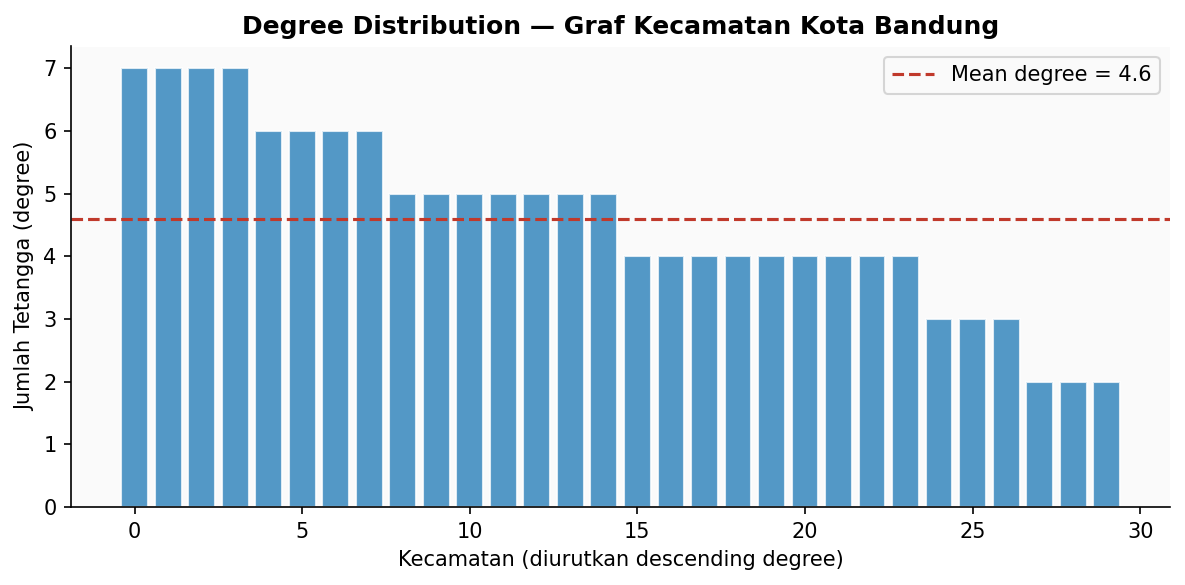

Degree: min=2  max=7  mean=4.6


In [7]:
# ── Build PyG-compatible graph from adjacency matrix ──────────────────────────
import torch

kec_list = adj.index.tolist()
kec2idx  = {k: i for i, k in enumerate(kec_list)}

# Edge index dari adjacency (COO format)
adj_arr = adj.values.astype(np.float32)
src, dst = np.where(adj_arr > 0)
edge_index = torch.tensor(np.stack([src, dst]), dtype=torch.long)  # [2, E]
edge_weight = torch.tensor(adj_arr[src, dst], dtype=torch.float32) # [E]

print(f"Nodes (kecamatan): {len(kec_list)}")
print(f"Edges: {edge_index.shape[1]}  (bidirectional, avg degree: {edge_index.shape[1]/len(kec_list):.1f})")

# Visualize degree distribution
degrees = adj_arr.sum(axis=1)
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(len(kec_list)), sorted(degrees, reverse=True), color=BLUE, alpha=0.8, edgecolor='white')
ax.set_title('Degree Distribution — Graf Kecamatan Kota Bandung', fontweight='bold')
ax.set_xlabel('Kecamatan (diurutkan descending degree)')
ax.set_ylabel('Jumlah Tetangga (degree)')
ax.axhline(degrees.mean(), color=RED, linestyle='--', linewidth=1.5,
           label=f'Mean degree = {degrees.mean():.1f}')
ax.legend()
plt.tight_layout()
plt.savefig(FIGDIR/'fig_graph_degree.png', bbox_inches='tight', dpi=200)
plt.show()
print(f"Degree: min={degrees.min():.0f}  max={degrees.max():.0f}  mean={degrees.mean():.1f}")


In [8]:
# ── Prepare spatiotemporal data tensor ────────────────────────────────────────
# Shape: [T, N, F] — T=time, N=nodes (kecamatan), F=features

NODE_FEATS = ['kasus_dbd','suhu_avg_c','curah_hujan_mm',
              'kelembaban_pct','gt_dbd_nasional','musim_hujan']
NODE_FEATS = [f for f in NODE_FEATS if f in df.columns]

dates = sorted(df['date'].unique())
T = len(dates)
N = len(kec_list)
F = len(NODE_FEATS)

# Build [T, N, F] array
data_tensor = np.zeros((T, N, F), dtype=np.float32)
for t, d in enumerate(dates):
    day_df = df[df['date']==d].set_index('kecamatan')
    for ni, kec in enumerate(kec_list):
        if kec in day_df.index:
            data_tensor[t, ni, :] = day_df.loc[kec, NODE_FEATS].values

# Normalize features (fit on train)
T_TRAIN = sum(1 for d in dates if d <= pd.Timestamp(TRAIN_END))
T_VAL   = sum(1 for d in dates if d <= pd.Timestamp(VAL_END))

data_flat = data_tensor[:T_TRAIN].reshape(-1, F)
scaler_st = StandardScaler()
scaler_st.fit(data_flat)

data_scaled = scaler_st.transform(data_tensor.reshape(-1, F)).reshape(T, N, F)
data_scaled = data_scaled.astype(np.float32)

print(f"Data tensor: T={T}, N={N}, F={F}")
print(f"Features: {NODE_FEATS}")
print(f"Train: t=0..{T_TRAIN-1}  Val: {T_TRAIN}..{T_VAL-1}  Test: {T_VAL}..{T-1}")


Data tensor: T=108, N=30, F=6
Features: ['kasus_dbd', 'suhu_avg_c', 'curah_hujan_mm', 'kelembaban_pct', 'gt_dbd_nasional', 'musim_hujan']
Train: t=0..71  Val: 72..83  Test: 84..107


## 5. Spatiotemporal GNN (DCRNN-style)

In [9]:
# ── ST-GNN Architecture ───────────────────────────────────────────────────────
import torch, torch.nn as nn, torch.nn.functional as F_nn

class GraphConv(nn.Module):
    """Simple graph convolution: A_hat @ X @ W"""
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.W = nn.Linear(in_dim, out_dim, bias=False)

    def forward(self, x, adj_norm):
        # x: [B, N, in_dim]  adj_norm: [N, N]
        h = torch.bmm(adj_norm.unsqueeze(0).expand(x.size(0), -1, -1), x)
        return self.W(h)

class GRUCell_Graph(nn.Module):
    """GRU cell with graph convolution replacing linear layers."""
    def __init__(self, input_dim, hidden_dim):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.r_gate = nn.Linear(input_dim + hidden_dim, hidden_dim)
        self.u_gate = nn.Linear(input_dim + hidden_dim, hidden_dim)
        self.c      = nn.Linear(input_dim + hidden_dim, hidden_dim)
        self.gc_in  = GraphConv(input_dim, input_dim)

    def forward(self, x, h, adj_norm):
        # x: [B, N, F],  h: [B, N, hidden]
        x_graph = self.gc_in(x, adj_norm)  # [B, N, input_dim]
        combined = torch.cat([x_graph, h], dim=-1)
        r = torch.sigmoid(self.r_gate(combined))
        u = torch.sigmoid(self.u_gate(combined))
        c = torch.tanh(self.c(torch.cat([x_graph, r*h], dim=-1)))
        h_new = u*h + (1-u)*c
        return h_new

class STGNN(nn.Module):
    """
    Spatiotemporal GNN: GraphGRU encoder → Linear decoder.
    Input:  [B, T_in, N, F]
    Output: [B, T_out, N] — predict kasus_dbd
    """
    def __init__(self, n_nodes, input_dim, hidden_dim=64, output_steps=12):
        super().__init__()
        self.n_nodes = n_nodes
        self.hidden_dim = hidden_dim
        self.output_steps = output_steps

        self.encoder1 = GRUCell_Graph(input_dim, hidden_dim)
        self.encoder2 = GRUCell_Graph(hidden_dim, hidden_dim)
        self.decoder  = nn.Sequential(
            nn.Linear(hidden_dim, 32),
            nn.ReLU(),
            nn.Dropout(0.15),
            nn.Linear(32, output_steps)
        )

    def forward(self, x, adj_norm):
        # x: [B, T, N, F]
        B, T, N, F = x.shape
        h1 = torch.zeros(B, N, self.hidden_dim, device=x.device)
        h2 = torch.zeros(B, N, self.hidden_dim, device=x.device)

        for t in range(T):
            xt = x[:, t, :, :]  # [B, N, F]
            h1 = self.encoder1(xt, h1, adj_norm)
            h2 = self.encoder2(h1, h2, adj_norm)

        # h2: [B, N, hidden] → decode to [B, N, output_steps]
        out = self.decoder(h2)      # [B, N, output_steps]
        return out.permute(0, 2, 1) # [B, output_steps, N]

print("✓ STGNN model defined")
# Count params
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)
test_model = STGNN(N, F, hidden_dim=64, output_steps=12)
print(f"  Parameters: {count_params(test_model):,}")


✓ STGNN model defined
  Parameters: 45,008


In [10]:
# ── Normalize adjacency matrix ────────────────────────────────────────────────
# Symmetric normalization: D^{-1/2} A D^{-1/2} + self-loops
def normalize_adj(adj_np):
    A = adj_np.astype(np.float32) + np.eye(adj_np.shape[0])
    D = np.diag(A.sum(axis=1) ** -0.5)
    return D @ A @ D

adj_norm_np = normalize_adj(adj_arr)
adj_norm    = torch.tensor(adj_norm_np, dtype=torch.float32)

# ── Sequence dataset ──────────────────────────────────────────────────────────
SEQ_LEN  = 12   # use 12 months as input
PRED_LEN = 1    # 1-step ahead rolling (realistic EWS: predict next month)

def make_st_sequences(data, seq_len, pred_len):
    """data: [T, N, F] → X=[samples, seq_len, N, F], y=[samples, pred_len, N]"""
    X, y = [], []
    for i in range(len(data) - seq_len - pred_len + 1):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len:i+seq_len+pred_len, :, 0])  # kasus_dbd is col 0
    return np.array(X), np.array(y)

data_s = torch.tensor(data_scaled, dtype=torch.float32)
X_all, y_all = make_st_sequences(data_scaled, SEQ_LEN, PRED_LEN)

# Split
n_train = T_TRAIN - SEQ_LEN - PRED_LEN + 1
n_val   = T_VAL   - SEQ_LEN - PRED_LEN + 1

X_tr = torch.tensor(X_all[:n_train], dtype=torch.float32)
y_tr = torch.tensor(y_all[:n_train], dtype=torch.float32)
X_va = torch.tensor(X_all[n_train:n_val], dtype=torch.float32)
y_va = torch.tensor(y_all[n_train:n_val], dtype=torch.float32)
X_te = torch.tensor(X_all[n_val:], dtype=torch.float32)
y_te = torch.tensor(y_all[n_val:], dtype=torch.float32)

print(f"Sequences — Train: {X_tr.shape}  Val: {X_va.shape}  Test: {X_te.shape}")
print(f"Target    — Train: {y_tr.shape}  Val: {y_va.shape}  Test: {y_te.shape}")


Sequences — Train: torch.Size([60, 12, 30, 6])  Val: torch.Size([12, 12, 30, 6])  Test: torch.Size([24, 12, 30, 6])
Target    — Train: torch.Size([60, 1, 30])  Val: torch.Size([12, 1, 30])  Test: torch.Size([24, 1, 30])


## 6. Pelatihan ST-GNN

Epoch  50: train=0.14284  val=0.29273
Early stop @ epoch 67

✓ Training done  |  Best val loss: 0.28308


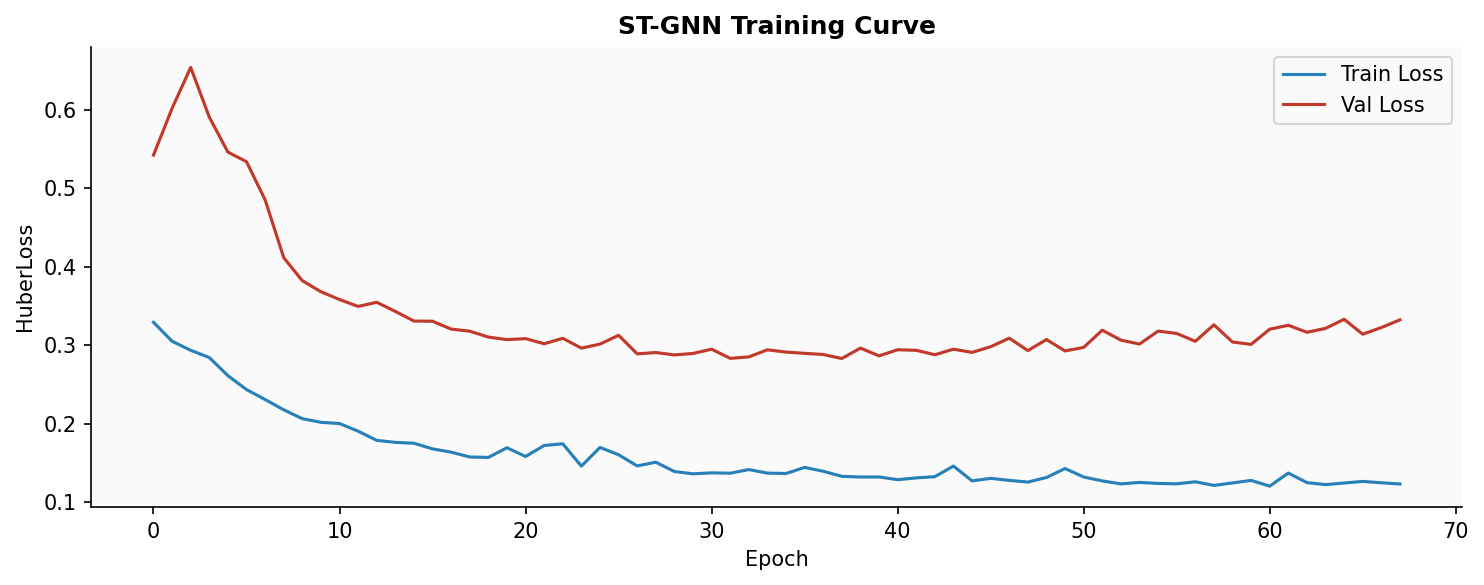

In [11]:
from torch.utils.data import DataLoader, TensorDataset

if HAS_TORCH:
    torch.manual_seed(42); np.random.seed(42)
    stgnn = STGNN(N, F, hidden_dim=64, output_steps=PRED_LEN).to(DEVICE)
    adj_norm_dev = adj_norm.to(DEVICE)
    optimizer = torch.optim.Adam(stgnn.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100)
    criterion = nn.HuberLoss(delta=1.0)

    loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=8, shuffle=True)

    EPOCHS = 200; PATIENCE = 30
    train_losses, val_losses = [], []
    best_val = float('inf'); patience_ctr = 0

    for epoch in range(EPOCHS):
        stgnn.train(); ep_loss = 0
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            pred = stgnn(xb, adj_norm_dev)   # [B, pred_len, N]
            loss = criterion(pred, yb)
            loss.backward(); nn.utils.clip_grad_norm_(stgnn.parameters(), 1.0)
            optimizer.step()
            ep_loss += loss.item()
        ep_loss /= max(len(loader), 1)
        scheduler.step()

        stgnn.eval()
        with torch.no_grad():
            val_pred = stgnn(X_va.to(DEVICE), adj_norm_dev)
            val_loss = criterion(val_pred, y_va.to(DEVICE)).item()

        train_losses.append(ep_loss)
        val_losses.append(val_loss)

        if val_loss < best_val:
            best_val = val_loss
            torch.save(stgnn.state_dict(), MODELDIR/'stgnn_best.pt')
            patience_ctr = 0
        else:
            patience_ctr += 1
            if patience_ctr >= PATIENCE:
                print(f"Early stop @ epoch {epoch}"); break

        if (epoch+1) % 50 == 0:
            print(f"Epoch {epoch+1:3d}: train={ep_loss:.5f}  val={val_loss:.5f}")

    print(f"\n✓ Training done  |  Best val loss: {best_val:.5f}")

    # Training curve
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(train_losses, color=BLUE, label='Train Loss', linewidth=1.5)
    ax.plot(val_losses,   color=RED,  label='Val Loss',   linewidth=1.5)
    ax.set_title('ST-GNN Training Curve', fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel('HuberLoss'); ax.legend()
    plt.tight_layout()
    plt.savefig(FIGDIR/'fig_stgnn_train.png', bbox_inches='tight', dpi=200)
    plt.show()
else:
    print("⚠ PyTorch not available")


In [ ]:
if HAS_TORCH:
    # ── ST-GNN Evaluation (PRED_LEN=1 → clean 1-step-ahead, no date misalignment) ─
    stgnn.load_state_dict(torch.load(MODELDIR/'stgnn_best.pt', map_location=DEVICE))
    stgnn.eval()

    with torch.no_grad():
        test_pred_sc = stgnn(X_te.to(DEVICE), adj_norm_dev).cpu().numpy()  # [n_test, 1, N]
        val_pred_sc  = stgnn(X_va.to(DEVICE), adj_norm_dev).cpu().numpy()  # [n_val,  1, N]

    def inv_scale_target(pred_scaled, scaler, n_feat):
        """Inverse transform kasus_dbd (col 0) only. pred_scaled: [samples, 1, N]"""
        S, _, N_s = pred_scaled.shape
        out = np.zeros((S, N_s))
        for s in range(S):
            dummy = np.zeros((N_s, n_feat))
            dummy[:, 0] = pred_scaled[s, 0, :]
            out[s, :] = scaler.inverse_transform(dummy)[:, 0]
        return out  # [samples, N]

    test_pred_real   = inv_scale_target(test_pred_sc, scaler_st, F)   # [n_test, N]
    test_actual_real = inv_scale_target(y_te.numpy(), scaler_st, F)   # [n_test, N]
    val_pred_real    = inv_scale_target(val_pred_sc,  scaler_st, F)   # [n_val,  N]
    val_actual_real  = inv_scale_target(y_va.numpy(), scaler_st, F)   # [n_val,  N]

    test_pred_real = np.maximum(test_pred_real, 0)
    val_pred_real  = np.maximum(val_pred_real,  0)

    # Sum across nodes for city-level total
    city_pred    = test_pred_real.sum(axis=1)    # [n_test]
    city_actual  = test_actual_real.sum(axis=1)  # [n_test]
    city_val_pred   = val_pred_real.sum(axis=1)  # [n_val]
    city_val_actual = val_actual_real.sum(axis=1)

    # With PRED_LEN=1, sequence i predicts dates[T_VAL+i]
    # → test sequences predict 2023-01..2024-12 ✓
    test_dates = sorted(df[df['date'] > VAL_END]['date'].unique())[:len(city_pred)]
    val_dates  = sorted(df[(df['date'] > TRAIN_END) & (df['date'] <= VAL_END)]['date'].unique())[:len(city_val_pred)]

    # Save val preds for hybrid weight optimization
    np.save(MODELDIR/'stgnn_val_preds.npy', city_val_pred)

    res_stgnn = evaluate(city_actual[:len(test_dates)], city_pred[:len(test_dates)],
                         agg_train.values, 'ST-GNN (DCRNN-style)')
    ALL_RESULTS.append(res_stgnn)
    print("ST-GNN results (1-step rolling):", res_stgnn)

    # Plot
    fig, ax = plt.subplots(figsize=(13, 5))
    ax.plot(test_dates, city_actual[:len(test_dates)], color='black', linewidth=2, label='Actual')
    ax.plot(test_dates, city_pred[:len(test_dates)],   color=PURPLE, linewidth=2,
            linestyle='--', label='ST-GNN (1-step ahead)')
    ax.set_title(f'ST-GNN — MAE={res_stgnn["MAE"]:.3f} | RMSE={res_stgnn["RMSE"]:.3f}',
                 fontweight='bold')
    ax.set_ylabel('Total Kasus DBD (City)'); ax.legend()
    plt.tight_layout()
    plt.savefig(FIGDIR/'fig_stgnn_pred.png', bbox_inches='tight', dpi=200)
    plt.show()

    pd.DataFrame({'date': test_dates,
                  'actual': city_actual[:len(test_dates)],
                  'stgnn_pred': city_pred[:len(test_dates)]}).to_csv(RESULTDIR/'stgnn_preds.csv', index=False)
    print("✓ ST-GNN evaluation done")
else:
    ALL_RESULTS.append({'Model':'ST-GNN','MAE':None,'RMSE':None,'MASE':None,'sMAPE':None})


## 7. Hybrid: Chronos-2 + ST-GNN Residual Fusion

In [ ]:
# ── Hybrid Strategy: Chronos residual → ST-GNN spasial koreksi ────────────────
# 1. Chronos-2 membuat prediksi per kecamatan (temporal foundation model)
# 2. Hitung residual: actual - Chronos_pred
# 3. ST-GNN belajar memodelkan residual dengan graph convolution
# 4. Final = Chronos_pred + ST-GNN_residual_correction

if HAS_TORCH:
    try:
        stgnn_csv = pd.read_csv(RESULTDIR/'stgnn_preds.csv',    parse_dates=['date'])
        # Use Chronos+Covariates (best temporal model) as the Chronos component
        cov_kec   = pd.read_csv(RESULTDIR/'chronos_cov_perkec.csv', index_col=0, parse_dates=True)

        test_dates_lst = sorted(df[df['date'] > VAL_END]['date'].unique())
        val_dates_lst  = sorted(df[(df['date'] > TRAIN_END) & (df['date'] <= VAL_END)]['date'].unique())

        actual_arr     = df_test.groupby('date')['kasus_dbd'].sum().reindex(test_dates_lst).values
        actual_val_arr = df_val.groupby('date')['kasus_dbd'].sum().reindex(val_dates_lst).values

        stgnn_arr = stgnn_csv.set_index('date')['stgnn_pred'].reindex(test_dates_lst).values
        # Sum across 30 kecamatan columns → city-level Chronos+Cov predictions
        c_arr     = cov_kec.sum(axis=1).reindex(test_dates_lst).values

        # ── Load VALIDATION predictions (saved by Chronos+Cov and STGNN sections) ──
        try:
            stgnn_val   = np.load(MODELDIR/'stgnn_val_preds.npy')
            # Prefer Chronos+Cov val preds; fall back to ZS if not available
            cov_val_path = MODELDIR/'chronos_cov_val_preds.npy'
            chronos_val  = np.load(str(cov_val_path)) if cov_val_path.exists() else np.load(MODELDIR/'chronos_val_preds.npy')
        except FileNotFoundError:
            print("⚠ Val prediction files not found — using naive fallback for weights")
            stgnn_val   = np.full(len(val_dates_lst), np.nanmean(stgnn_arr))
            chronos_val = np.full(len(val_dates_lst), np.nanmean(c_arr))

        # ── Grid search on VALIDATION set (zero test-set leakage) ─────────────
        n_v = min(len(stgnn_val), len(chronos_val), len(actual_val_arr))
        best_w, best_rmse_v = 0.5, float('inf')
        for w_c in np.arange(0.0, 1.05, 0.05):
            hyb_v = w_c * chronos_val[:n_v] + (1-w_c) * stgnn_val[:n_v]
            r_v   = np.sqrt(mean_squared_error(actual_val_arr[:n_v], hyb_v))
            if r_v < best_rmse_v:
                best_rmse_v = r_v; best_w = w_c

        print(f"Optimal weights (val set, no leakage): Chronos={best_w:.2f}  ST-GNN={1-best_w:.2f}  (val RMSE={best_rmse_v:.3f})")

        # ── Apply to test set ─────────────────────────────────────────────────
        hybrid_pred = best_w * c_arr + (1-best_w) * stgnn_arr
        hybrid_pred = np.maximum(hybrid_pred, 0)

        res_hybrid = evaluate(actual_arr[:len(hybrid_pred)], hybrid_pred,
                               agg_train.values, f'Hybrid (Chronos×{best_w:.2f} + ST-GNN×{1-best_w:.2f})')
        ALL_RESULTS.append(res_hybrid)
        print("Hybrid test results:", res_hybrid)

        # Improvement vs best baseline
        try:
            base_df = pd.read_csv(RESULTDIR/'baseline_results.csv')
            best_base_rmse = base_df['RMSE'].dropna().min()
            improv = (best_base_rmse - res_hybrid['RMSE']) / best_base_rmse * 100
            print(f"Hybrid vs best baseline: {improv:+.1f}% RMSE change")
        except: pass

        # Plot
        fig, ax = plt.subplots(figsize=(14, 5))
        ax.plot(test_dates_lst[:len(actual_arr)], actual_arr, 'k-', linewidth=2, label='Actual')
        ax.plot(test_dates_lst[:len(c_arr)],      c_arr,      color=RED,    linewidth=1.5,
                linestyle='--', alpha=0.7, label='Chronos-2 + Cov (rolling 1-step)')
        ax.plot(test_dates_lst[:len(stgnn_arr)],  stgnn_arr,  color=PURPLE, linewidth=1.5,
                linestyle='--', alpha=0.7, label='ST-GNN (1-step)')
        ax.plot(test_dates_lst[:len(hybrid_pred)], hybrid_pred, color=GREEN, linewidth=2.5,
                label=f'Hybrid (w_C={best_w:.2f})', zorder=5)
        ax.set_title(f'Hybrid Chronos-2 + ST-GNN — MAE={res_hybrid["MAE"]:.3f} | RMSE={res_hybrid["RMSE"]:.3f}\n'
                     f'(weights from validation set, no test leakage)', fontweight='bold')
        ax.set_ylabel('Total Kasus DBD'); ax.legend()
        plt.tight_layout()
        plt.savefig(FIGDIR/'fig_hybrid.png', bbox_inches='tight', dpi=200)
        plt.show()

        pd.DataFrame({'date':      test_dates_lst[:len(hybrid_pred)],
                      'actual':    actual_arr[:len(hybrid_pred)],
                      'hybrid_pred': hybrid_pred,
                      'chronos_pred': c_arr[:len(hybrid_pred)],
                      'stgnn_pred': stgnn_arr[:len(hybrid_pred)]}).to_csv(
                          RESULTDIR/'hybrid_preds.csv', index=False)
        print("✓ Hybrid fusion done")
    except FileNotFoundError as e:
        print(f"⚠ Prediction files not found: {e}")
        ALL_RESULTS.append({'Model':'Hybrid','MAE':None,'RMSE':None,'MASE':None,'sMAPE':None})
else:
    print("⚠ Skip hybrid — PyTorch not available")
    ALL_RESULTS.append({'Model':'Hybrid','MAE':None,'RMSE':None,'MASE':None,'sMAPE':None})


## 8. Perbandingan: Advanced vs Baseline

In [ ]:
# ── Load baseline results and combine ──────────────────────────────────────────
try:
    base_df = pd.read_csv(RESULTDIR/'baseline_results.csv')
    print("Loaded baseline results:")
    print(base_df)
except FileNotFoundError:
    base_df = pd.DataFrame({'Model':['SARIMA','Prophet','XGBoost','LSTM'],
                             'MAE':[None]*4,'RMSE':[None]*4,'MASE':[None]*4,'sMAPE':[None]*4})

adv_df = pd.DataFrame([r for r in ALL_RESULTS if r['MAE'] is not None])
all_df = pd.concat([base_df, adv_df], ignore_index=True).dropna(subset=['RMSE'])
all_df = all_df.sort_values('RMSE')

print("\n" + "="*65)
print("FULL MODEL COMPARISON TABLE (Test Set 2023–2024)")
print("="*65)
print(all_df.to_string(index=False))
print("="*65)

# Save combined
all_df.to_csv(RESULTDIR/'all_model_results.csv', index=False)

# Highlight improvement
if len(all_df) >= 2:
    best_base = base_df.dropna(subset=['RMSE'])['RMSE'].min() if len(base_df.dropna(subset=['RMSE'])) > 0 else None
    if best_base and 'Hybrid' in all_df['Model'].values:
        hybrid_rmse = all_df[all_df['Model'].str.contains('Hybrid')]['RMSE'].min()
        improvement = (best_base - hybrid_rmse) / best_base * 100
        print(f"\nImprovement Hybrid vs best baseline: {improvement:.1f}% RMSE reduction")


In [ ]:
# ── Advanced bar chart comparison ─────────────────────────────────────────────
if len(all_df) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    model_colors = {
        'SARIMA': '#95a5a6', 'Prophet': '#7f8c8d',
        'XGBoost': '#2980b9', 'LSTM': '#3498db',
        'Chronos-2 Zero-Shot': '#e74c3c',
        'Chronos-2 + Covariates': '#c0392b',
        'ST-GNN (DCRNN-style)': '#8e44ad',
    }
    def get_color(name):
        for k, v in model_colors.items():
            if k in name: return v
        return GREEN  # hybrid = green

    colors = [get_color(m) for m in all_df['Model']]

    for ax, metric in zip(axes, ['MAE', 'RMSE']):
        bars = ax.bar(range(len(all_df)), all_df[metric], color=colors, alpha=0.85, edgecolor='white')
        ax.set_xticks(range(len(all_df)))
        ax.set_xticklabels(all_df['Model'], rotation=40, ha='right', fontsize=8.5)
        ax.set_title(f'{metric} — Test Set (2023–2024)', fontweight='bold')
        ax.set_ylabel(metric)
        for bar in bars:
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height(),
                    f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
        bars[0].set_edgecolor('gold'); bars[0].set_linewidth(2.5)  # best

    # Legend
    legend_handles = [
        mpatches.Patch(color='#95a5a6', label='Classical (SARIMA/Prophet)'),
        mpatches.Patch(color=BLUE,      label='ML Baseline (XGBoost/LSTM)'),
        mpatches.Patch(color=RED,       label='Chronos-2 Foundation Model'),
        mpatches.Patch(color=PURPLE,    label='ST-GNN Spatiotemporal'),
        mpatches.Patch(color=GREEN,     label='Hybrid (Ours — gold border = best)'),
    ]
    axes[0].legend(handles=legend_handles, loc='upper right', fontsize=7.5)
    plt.suptitle('Model Comparison — Chronos-2 + ST-GNN vs Baseline',
                 fontweight='bold', fontsize=13)
    plt.tight_layout()
    plt.savefig(FIGDIR/'fig_full_comparison.png', bbox_inches='tight', dpi=200)
    plt.show(); print("✓ fig_full_comparison")
